<a href="https://colab.research.google.com/github/yohperez/EjemplosMates/blob/main/vida_cuantica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌌 Vida Cuántica — Autómata Celular 3D

Simulación de vida artificial usando **matrices NumPy 3D** con visualización en terminal.

### Reglas del universo:
- Una célula **VIVA** sobrevive si tiene entre 4 y 6 vecinos vivos
- Una célula **MUERTA** nace si tiene exactamente 5 vecinos vivos
- El espacio es un **cubo 3D toroidal** (los bordes se conectan)

---

## 1. Importaciones y Paleta de Colores ANSI

In [1]:
import numpy as np
import time
import os
import random

In [2]:
class Color:
    RESET   = "\033[0m"
    BOLD    = "\033[1m"

    # Células por densidad de vecinos (gradiente de color)
    NIVELES = [
        "\033[38;5;17m",   # 0 vecinos → azul muy oscuro
        "\033[38;5;21m",   # 1 vecino  → azul
        "\033[38;5;39m",   # 2 vecinos → azul claro
        "\033[38;5;51m",   # 3 vecinos → cian
        "\033[38;5;82m",   # 4 vecinos → verde neón
        "\033[38;5;226m",  # 5 vecinos → amarillo
        "\033[38;5;208m",  # 6 vecinos → naranja
        "\033[38;5;196m",  # 7+ vecinos → rojo intenso
    ]

    TITULO   = "\033[38;5;201m"
    INFO     = "\033[38;5;250m"
    ACENTO   = "\033[38;5;45m"
    MUERTO   = "\033[38;5;238m"


# Símbolos visuales para las células
CELULA_VIVA   = ["▓", "█", "◉", "⬡", "✦", "★"]
CELULA_MUERTA = "·"
SEPARADOR     = "  "

print("✅ Colores y símbolos definidos correctamente.")

✅ Colores y símbolos definidos correctamente.


---
## 2. Núcleo: Creación y Evolución de Matrices 3D

In [3]:
def crear_universo(filas: int, cols: int, capas: int, densidad: float = 0.35) -> np.ndarray:
    """
    Crea una matriz 3D de células vivas/muertas de forma aleatoria.

    Args:
        filas    : Número de filas (eje Y)
        cols     : Número de columnas (eje X)
        capas    : Profundidad del cubo (eje Z)
        densidad : Proporción inicial de células vivas (0.0 - 1.0)

    Returns:
        np.ndarray de forma (capas, filas, cols) con valores 0 o 1
    """
    return (np.random.rand(capas, filas, cols) < densidad).astype(np.int8)


# Visualizar la matriz cruda
universo_prueba = crear_universo(4, 6, 2, densidad=0.4)
print("Forma de la matriz 3D:", universo_prueba.shape)
print("\nCapa Z=0:")
print(universo_prueba[0])
print("\nCapa Z=1:")
print(universo_prueba[1])

Forma de la matriz 3D: (2, 4, 6)

Capa Z=0:
[[0 1 0 0 1 0]
 [1 0 0 0 1 0]
 [0 0 0 1 1 0]
 [1 1 1 1 0 0]]

Capa Z=1:
[[1 1 0 1 1 0]
 [0 0 0 1 0 1]
 [1 0 0 1 1 0]
 [0 1 1 1 0 0]]


In [ ]:
def contar_vecinos_3d(universo: np.ndarray) -> np.ndarray:
    """
    Cuenta los vecinos vivos de cada célula en las 26 direcciones
    posibles del espacio 3D usando np.roll (convolución toroidal).

    El universo es TOROIDAL: los bordes se conectan entre sí.
    """
    vecinos = np.zeros_like(universo, dtype=np.int8)

    for dz in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dz == 0 and dy == 0 and dx == 0:
                    continue  # No contarse a sí mismo
                vecinos += np.roll(
                    np.roll(
                        np.roll(universo, dz, axis=0),
                        dy, axis=1
                    ),
                    dx, axis=2
                )
    return vecinos


# Verificar conteo de vecinos
vecinos_prueba = contar_vecinos_3d(universo_prueba)
print("Vecinos en Capa Z=0:")
print(vecinos_prueba[0])
print(f"\nMáx vecinos posibles en 3D: 26 | Máximo encontrado: {vecinos_prueba.max()}")

Vecinos en Capa Z=0:
[[10  8  7  9 10 11]
 [12 13 15 13 10 10]
 [13 11 10 10 12 13]
 [10  9 12 12 13  9]]

Máx vecinos posibles en 3D: 26 | Máximo encontrado: 15


In [ ]:
def evolucionar(universo: np.ndarray, nacer: set, sobrevivir: set) -> np.ndarray:
    """
    Aplica las reglas de vida/muerte usando operaciones matriciales puras.

    Args:
        universo  : Matriz 3D actual
        nacer     : Conjunto de vecinos necesarios para que una célula nazca
        sobrevivir: Conjunto de vecinos para que una célula sobreviva

    Returns:
        Nueva matriz 3D con el estado actualizado
    """
    vecinos = contar_vecinos_3d(universo)

    vivo   = universo == 1
    muerto = universo == 0

    sobrevive_mask = np.zeros_like(universo, dtype=bool)
    nace_mask      = np.zeros_like(universo, dtype=bool)

    for n in sobrevivir:
        sobrevive_mask |= (vivo & (vecinos == n))
    for n in nacer:
        nace_mask |= (muerto & (vecinos == n))

    nuevo_universo = np.zeros_like(universo)
    nuevo_universo[sobrevive_mask] = 1
    nuevo_universo[nace_mask]      = 1

    return nuevo_universo


# Evolucionar una generación
siguiente = evolucionar(universo_prueba, nacer={5}, sobrevivir={4, 5, 6})
print("Células vivas antes:", universo_prueba.sum())
print("Células vivas después:", siguiente.sum())

Células vivas antes: 19
Células vivas después: 2


---
## 3. Visualización: Proyección 2D del Cubo

In [4]:
def renderizar(universo: np.ndarray, generacion: int, densidad_total: float,
               reglas_nombre: str, simbolo_idx: int):
    """Dibuja el universo 3D como capas 2D lado a lado en la terminal."""

    capas, filas, cols = universo.shape
    vecinos = contar_vecinos_3d(universo)
    simbolo = CELULA_VIVA[simbolo_idx % len(CELULA_VIVA)]

    print("\033[H\033[J", end="")

    ancho_total = capas * (cols * 2 + 3)
    print(Color.TITULO + Color.BOLD)
    print("  ╔" + "═" * (ancho_total + 2) + "╗")
    print(f"  ║  🌌  VIDA CUÁNTICA 3D  ·  {reglas_nombre:<30}║")
    print("  ╚" + "═" * (ancho_total + 2) + "╝" + Color.RESET)

    linea_capas = "  "
    for z in range(capas):
        etiq = f" Capa Z={z} "
        linea_capas += Color.ACENTO + etiq.center(cols * 2 + 2) + Color.RESET + SEPARADOR
    print(linea_capas)
    print()

    for y in range(filas):
        fila_str = "  "
        for z in range(capas):
            for x in range(cols):
                estado  = universo[z, y, x]
                n_vivos = vecinos[z, y, x]

                if estado == 1:
                    nivel = min(n_vivos, len(Color.NIVELES) - 1)
                    fila_str += Color.NIVELES[nivel] + simbolo + " " + Color.RESET
                else:
                    fila_str += Color.MUERTO + CELULA_MUERTA + " " + Color.RESET
            fila_str += SEPARADOR
        print(fila_str)

    vivas = int(universo.sum())
    total = universo.size

    print()
    print(Color.INFO + "  " + "─" * (ancho_total + 2) + Color.RESET)
    print(
        f"  {Color.ACENTO}Gen {generacion:>4}{Color.RESET}  │  "
        f"{Color.NIVELES[4]}Vivas: {vivas:>4}{Color.RESET}  │  "
        f"{Color.MUERTO}Muertas: {total - vivas:>4}{Color.RESET}  │  "
        f"Densidad: {vivas/total*100:5.1f}%  │  "
        f"Inercia inicial: {densidad_total*100:.0f}%"
    )
    print()
    print(Color.INFO + "  Leyenda: ", end="")
    for i, lv in enumerate(Color.NIVELES):
        print(lv + f"[{i}vec] " + Color.RESET, end="")
    print()
    print(Color.INFO + "  Presiona Ctrl+C para salir" + Color.RESET)


print("✅ Función de renderizado lista.")

✅ Función de renderizado lista.


---
## 4. Presets de Universos (distintas reglas)

In [5]:
UNIVERSOS = [
    {
        "nombre":     "Cuántico Clásico      ",
        "nacer":      {5},
        "sobrevivir": {4, 5, 6},
        "densidad":   0.35,
    },
    {
        "nombre":     "Expansión Caótica     ",
        "nacer":      {4, 5},
        "sobrevivir": {3, 4, 5, 6},
        "densidad":   0.25,
    },
    {
        "nombre":     "Cristal de Hielo      ",
        "nacer":      {6},
        "sobrevivir": {5, 6, 7},
        "densidad":   0.45,
    },
    {
        "nombre":     "Plasma Inestable      ",
        "nacer":      {3, 4, 5, 6},
        "sobrevivir": {2, 3},
        "densidad":   0.20,
    },
]

# Mostrar resumen de los universos disponibles
print("🌌 Universos disponibles:\n")
for i, u in enumerate(UNIVERSOS):
    print(f"  [{i}] {u['nombre']} | Nacer: {sorted(u['nacer'])} | "
          f"Sobrevivir: {sorted(u['sobrevivir'])} | Densidad: {u['densidad']*100:.0f}%")

🌌 Universos disponibles:

  [0] Cuántico Clásico       | Nacer: [5] | Sobrevivir: [4, 5, 6] | Densidad: 35%
  [1] Expansión Caótica      | Nacer: [4, 5] | Sobrevivir: [3, 4, 5, 6] | Densidad: 25%
  [2] Cristal de Hielo       | Nacer: [6] | Sobrevivir: [5, 6, 7] | Densidad: 45%
  [3] Plasma Inestable       | Nacer: [3, 4, 5, 6] | Sobrevivir: [2, 3] | Densidad: 20%


---
## 5. ▶️ Ejecutar la Simulación

Modifica `UNIVERSO_IDX` para elegir el universo (0–3), o ponlo en `None` para uno aleatorio.

> ⚠️ **Nota:** La animación funciona mejor en una terminal. En Jupyter verás la salida generación a generación. Usa `MAX_GENERACIONES` para limitar la ejecución.

In [6]:
# ─── Parámetros configurables ───────────────────────
UNIVERSO_IDX    = 0      # 0, 1, 2, 3 o None para aleatorio
FILAS           = 16
COLS            = 20
CAPAS           = 3
FPS             = 8
MAX_GENERACIONES = 30   # Cambia a None para correr indefinidamente
# ────────────────────────────────────────────────────

if UNIVERSO_IDX is None:
    config = {
        "nombre":     "Universo Aleatorio    ",
        "nacer":      set(random.sample(range(1, 14), random.randint(1, 4))),
        "sobrevivir": set(random.sample(range(1, 14), random.randint(2, 5))),
        "densidad":   random.uniform(0.2, 0.5),
    }
else:
    config = UNIVERSOS[UNIVERSO_IDX]

universo  = crear_universo(FILAS, COLS, CAPAS, config["densidad"])
anterior  = None
gen       = 0
simbolo_i = 0

print(f"🚀 Iniciando: {config['nombre'].strip()}")
print(f"   Dimensiones: {CAPAS} capas × {FILAS} filas × {COLS} cols")
print(f"   Densidad inicial: {config['densidad']*100:.0f}%")
print(f"   Reglas → Nacer: {sorted(config['nacer'])} | Sobrevivir: {sorted(config['sobrevivir'])}\n")

try:
    while True:
        renderizar(universo, gen, config["densidad"], config["nombre"], simbolo_i)

        if anterior is not None and np.array_equal(universo, anterior):
            print("\n⚡ Universo estabilizado — reiniciando con nueva semilla...")
            time.sleep(2)
            universo  = crear_universo(FILAS, COLS, CAPAS, config["densidad"])
            gen       = 0
            anterior  = None
            simbolo_i += 1
            continue

        anterior = universo.copy()
        universo = evolucionar(universo, config["nacer"], config["sobrevivir"])
        gen     += 1

        if MAX_GENERACIONES and gen >= MAX_GENERACIONES:
            print(f"\n✅ Simulación completada: {gen} generaciones.")
            break

        time.sleep(1 / FPS)

except KeyboardInterrupt:
    print("\n\n🌌 Universo disuelto. ¡Hasta la próxima simulación!")

🚀 Iniciando: Cuántico Clásico
   Dimensiones: 3 capas × 16 filas × 20 cols
   Densidad inicial: 35%
   Reglas → Nacer: [5] | Sobrevivir: [4, 5, 6]



NameError: name 'contar_vecinos_3d' is not defined

In [13]:
import numpy as np
import time
import os
import random

In [14]:
class Color:
    RESET   = "\033[0m"
    BOLD    = "\033[1m"

    # Células por densidad de vecinos (gradiente de color)
    NIVELES = [
        "\033[38;5;17m",   # 0 vecinos → azul muy oscuro
        "\033[38;5;21m",   # 1 vecino  → azul
        "\033[38;5;39m",   # 2 vecinos → azul claro
        "\033[38;5;51m",   # 3 vecinos → cian
        "\033[38;5;82m",   # 4 vecinos → verde neón
        "\033[38;5;226m",  # 5 vecinos → amarillo
        "\033[38;5;208m",  # 6 vecinos → naranja
        "\033[38;5;196m",  # 7+ vecinos → rojo intenso
    ]

    TITULO   = "\033[38;5;201m"
    INFO     = "\033[38;5;250m"
    ACENTO   = "\033[38;5;45m"
    MUERTO   = "\033[38;5;238m"


# Símbolos visuales para las células
CELULA_VIVA   = ["▓", "█", "◉", "⬡", "✦", "★"]
CELULA_MUERTA = "·"
SEPARADOR     = "  "

print("✅ Colores y símbolos definidos correctamente.")

✅ Colores y símbolos definidos correctamente.


In [15]:
def crear_universo(filas: int, cols: int, capas: int, densidad: float = 0.35) -> np.ndarray:
    """
    Crea una matriz 3D de células vivas/muertas de forma aleatoria.

    Args:
        filas    : Número de filas (eje Y)
        cols     : Número de columnas (eje X)
        capas    : Profundidad del cubo (eje Z)
        densidad : Proporción inicial de células vivas (0.0 - 1.0)

    Returns:
        np.ndarray de forma (capas, filas, cols) con valores 0 o 1
    """
    return (np.random.rand(capas, filas, cols) < densidad).astype(np.int8)

In [16]:
def contar_vecinos_3d(universo: np.ndarray) -> np.ndarray:
    """
    Cuenta los vecinos vivos de cada célula en las 26 direcciones
    posibles del espacio 3D usando np.roll (convolución toroidal).

    El universo es TOROIDAL: los bordes se conectan entre sí.
    """
    vecinos = np.zeros_like(universo, dtype=np.int8)

    for dz in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dz == 0 and dy == 0 and dx == 0:
                    continue  # No contarse a sí mismo
                vecinos += np.roll(
                    np.roll(
                        np.roll(universo, dz, axis=0),
                        dy, axis=1
                    ),
                    dx, axis=2
                )
    return vecinos

In [17]:
def evolucionar(universo: np.ndarray, nacer: set, sobrevivir: set) -> np.ndarray:
    """
    Aplica las reglas de vida/muerte usando operaciones matriciales puras.

    Args:
        universo  : Matriz 3D actual
        nacer     : Conjunto de vecinos necesarios para que una célula nazca
        sobrevivir: Conjunto de vecinos para que una célula sobreviva

    Returns:
        Nueva matriz 3D con el estado actualizado
    """
    vecinos = contar_vecinos_3d(universo)

    vivo   = universo == 1
    muerto = universo == 0

    sobrevive_mask = np.zeros_like(universo, dtype=bool)
    nace_mask      = np.zeros_like(universo, dtype=bool)

    for n in sobrevivir:
        sobrevive_mask |= (vivo & (vecinos == n))
    for n in nacer:
        nace_mask |= (muerto & (vecinos == n))

    nuevo_universo = np.zeros_like(universo)
    nuevo_universo[sobrevive_mask] = 1
    nuevo_universo[nace_mask]      = 1

    return nuevo_universo

In [18]:
def renderizar(universo: np.ndarray, generacion: int, densidad_total: float,
               reglas_nombre: str, simbolo_idx: int):
    """Dibuja el universo 3D como capas 2D lado a lado en la terminal."""

    capas, filas, cols = universo.shape
    vecinos = contar_vecinos_3d(universo)
    simbolo = CELULA_VIVA[simbolo_idx % len(CELULA_VIVA)]

    print("\033[H\033[J", end="")

    ancho_total = capas * (cols * 2 + 3)
    print(Color.TITULO + Color.BOLD)
    print("  ╔" + "═" * (ancho_total + 2) + "╗")
    print(f"  ║  🌌  VIDA CUÁNTICA 3D  ·  {reglas_nombre:<30}║")
    print("  ╚" + "═" * (ancho_total + 2) + "╝" + Color.RESET)

    linea_capas = "  "
    for z in range(capas):
        etiq = f" Capa Z={z} "
        linea_capas += Color.ACENTO + etiq.center(cols * 2 + 2) + Color.RESET + SEPARADOR
    print(linea_capas)
    print()

    for y in range(filas):
        fila_str = "  "
        for z in range(capas):
            for x in range(cols):
                estado  = universo[z, y, x]
                n_vivos = vecinos[z, y, x]

                if estado == 1:
                    nivel = min(n_vivos, len(Color.NIVELES) - 1)
                    fila_str += Color.NIVELES[nivel] + simbolo + " " + Color.RESET
                else:
                    fila_str += Color.MUERTO + CELULA_MUERTA + " " + Color.RESET
            fila_str += SEPARADOR
        print(fila_str)

    vivas = int(universo.sum())
    total = universo.size

    print()
    print(Color.INFO + "  " + "─" * (ancho_total + 2) + Color.RESET)
    print(
        f"  {Color.ACENTO}Gen {generacion:>4}{Color.RESET}  │  "
        f"{Color.NIVELES[4]}Vivas: {vivas:>4}{Color.RESET}  │  "
        f"{Color.MUERTO}Muertas: {total - vivas:>4}{Color.RESET}  │  "
        f"Densidad: {vivas/total*100:5.1f}%  │  "
        f"Inercia inicial: {densidad_total*100:.0f}%"
    )
    print()
    print(Color.INFO + "  Leyenda: ", end="")
    for i, lv in enumerate(Color.NIVELES):
        print(lv + f"[{i}vec] " + Color.RESET, end="")
    print()
    print(Color.INFO + "  Presiona Ctrl+C para salir" + Color.RESET)

---
## 6. 📊 Análisis Estadístico de la Evolución

/tmp/ipykernel_5136/2394512506.py:42: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


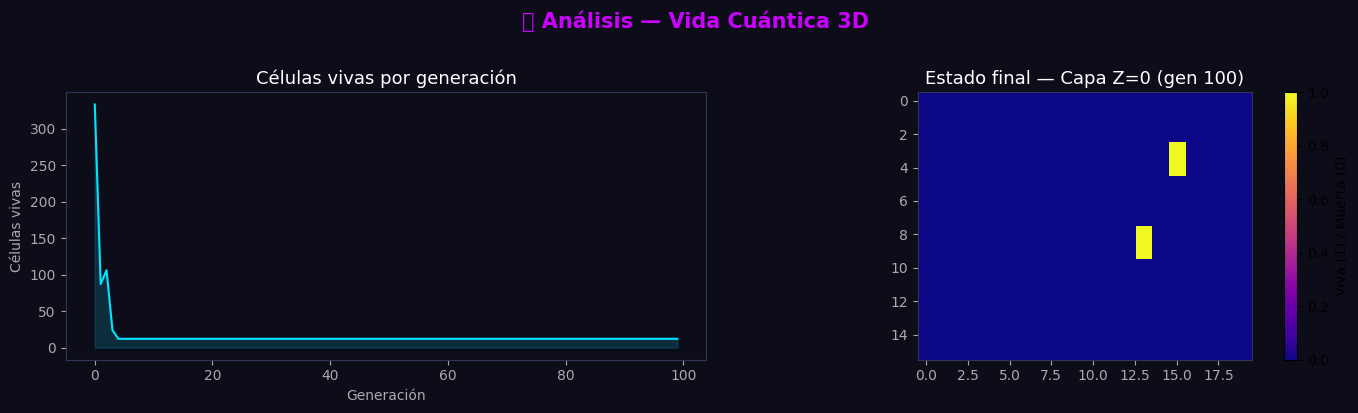


Estadísticas finales:
  Promedio células vivas : 17.0
  Máximo                 : 333
  Mínimo                 : 12
  Desviación estándar    : 33.93


In [19]:
import matplotlib.pyplot as plt

# Simular N generaciones y guardar estadísticas
N_GEN     = 100
config    = UNIVERSOS[0]  # Cuántico Clásico
universo  = crear_universo(FILAS, COLS, CAPAS, config["densidad"])

historial_vivas = []

for _ in range(N_GEN):
    historial_vivas.append(int(universo.sum()))
    universo = evolucionar(universo, config["nacer"], config["sobrevivir"])

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor("#0d0d1a")

# Gráfico 1: Células vivas por generación
ax1 = axes[0]
ax1.set_facecolor("#0d0d1a")
ax1.plot(historial_vivas, color="#00e5ff", linewidth=1.5)
ax1.fill_between(range(N_GEN), historial_vivas, alpha=0.15, color="#00e5ff")
ax1.set_title("Células vivas por generación", color="white", fontsize=13)
ax1.set_xlabel("Generación", color="#aaaaaa")
ax1.set_ylabel("Células vivas", color="#aaaaaa")
ax1.tick_params(colors="#aaaaaa")
for spine in ax1.spines.values():
    spine.set_edgecolor("#333355")

# Gráfico 2: Mapa de calor de la última capa Z=0
ax2 = axes[1]
ax2.set_facecolor("#0d0d1a")
im = ax2.imshow(universo[0], cmap="plasma", interpolation="nearest")
ax2.set_title(f"Estado final — Capa Z=0 (gen {N_GEN})", color="white", fontsize=13)
ax2.tick_params(colors="#aaaaaa")
for spine in ax2.spines.values():
    spine.set_edgecolor("#333355")
plt.colorbar(im, ax=ax2, label="Viva (1) / Muerta (0)")

plt.suptitle("🌌 Análisis — Vida Cuántica 3D", color="#cc00ff",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nEstadísticas finales:")
print(f"  Promedio células vivas : {np.mean(historial_vivas):.1f}")
print(f"  Máximo                 : {max(historial_vivas)}")
print(f"  Mínimo                 : {min(historial_vivas)}")
print(f"  Desviación estándar    : {np.std(historial_vivas):.2f}")